<a href="https://colab.research.google.com/github/victoriairungu99-creator/CDAV-course/blob/main/Loan_Case_study_Exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Loan Application Data Analysis

This notebook analyzes a loan application dataset to understand applicant characteristics, loan amounts, income patterns, outliers, relationships between variables, and factors associated with loan approval. The analysis uses descriptive statistics and visualizations to identify and interpret key patterns in the data.


In [9]:
#Import librarirs
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [10]:
#Load dataset
loan=pd.read_csv("/content/loan_data.csv")
#Show first five rows
loan.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128,360.0,1.0,Rural,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66,360.0,1.0,Urban,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120,360.0,1.0,Urban,Y
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141,360.0,1.0,Urban,Y
4,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95,360.0,1.0,Urban,Y


In [15]:
#No. of rows and column in dataset
loan.shape
print("Shape of dataset:",loan.shape)

Shape of dataset: (381, 13)


In [12]:
#View column data types and missing value counts
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381 entries, 0 to 380
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            381 non-null    object 
 1   Gender             376 non-null    object 
 2   Married            381 non-null    object 
 3   Dependents         373 non-null    object 
 4   Education          381 non-null    object 
 5   Self_Employed      360 non-null    object 
 6   ApplicantIncome    381 non-null    int64  
 7   CoapplicantIncome  381 non-null    float64
 8   LoanAmount         381 non-null    int64  
 9   Loan_Amount_Term   370 non-null    float64
 10  Credit_History     351 non-null    float64
 11  Property_Area      381 non-null    object 
 12  Loan_Status        381 non-null    object 
dtypes: float64(3), int64(2), object(8)
memory usage: 38.8+ KB


In [13]:
loan.isnull().sum()

,0
Loan_ID,0
Gender,5
Married,0
Dependents,8
Education,0
Self_Employed,21
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,11


In [16]:

# STEP 1: IMPUTE MISSING VALUES (MODE FILL)
# Missing values are in categorical / discrete columns, so we fill them with their mode (most frequent value)
columns_to_impute = [
    'Gender',
    'Dependents',
    'Self_Employed',
    'Credit_History',
    'Loan_Amount_Term',
]

for col in columns_to_impute:
  mode_val = loan[col].mode()[0]
  loan[col] = loan[col].fillna(mode_val)

# STEP 2: FIX & CONVERT DATA TYPES
# Convert Loan_Amount_Term from float64 to clean int64 (months)
loan['Loan_Amount_Term'] = loan['Loan_Amount_Term'].astype(int)

# Convert Credit_History from float64 to category (1 = Yes, 0 = No)
loan['Credit_History'] = loan['Credit_History'].astype(int)

# Leave 'Loan_ID' as string/object (unique identifier)
# 'ApplicantIncome', 'CoapplicantIncome', and 'LoanAmount' remain numeric (int64 / float64)

# STEP 3: VERIFY CLEAN DATASET
print("Missing values count after cleaning:\n", loan.isnull().sum())
print("\nFinal clean data types:\n", loan.dtypes)

Missing values count after cleaning:
 Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

Final clean data types:
 Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount             int64
Loan_Amount_Term       int64
Credit_History         int64
Property_Area         object
Loan_Status           object
dtype: object


In [21]:
# Define numerical variables for analysis
num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']

# Compute summary statistics
summary_stats = pd.DataFrame({
    'Mean':     loan[num_cols].mean(),
    'Median':   loan[num_cols].median(),
    'Variance': loan[num_cols].var(),
    'Std Dev':  loan[num_cols].std(),
    'IQR':      loan[num_cols].quantile(0.75) - loan[num_cols].quantile(0.25),
    'Min':      loan[num_cols].min(),
    'Max':       loan[num_cols].max(),
})

print(summary_stats.round(2))

                      Mean  Median    Variance  Std Dev     IQR    Min  \
ApplicantIncome    3579.85  3333.0  2015871.28  1419.81  1688.0  150.0   
CoapplicantIncome  1277.28   983.0  5479429.44  2340.82  2016.0    0.0   
LoanAmount          104.99   110.0      804.20    28.36    37.0    9.0   

                       Max  
ApplicantIncome     9703.0  
CoapplicantIncome  33837.0  
LoanAmount           150.0  


#Interpretation of results
Applicant Income: The typical applicant brings in a middle (median) income of $3,333 per month. The arithmetic average of $3579.85 is slightly higher because a handful of higher earners(upto $9703) pull the number up.

There is a wide spread in borrower earnings, shown by a standard deviation of $1,419.81 and an IQR of $1,688.00.

Co-applicant Income: The median sits at $983 per month, while the average jumps to $1,277.28. This large difference happens because nearly 46% of applicants applied alone with $0 co-applicant earnings, while a few very high earners (up to $33,837) push the average higher. This makes it the most uneven and volatile variable in the dataset, with a standard deviation of $2,340.82.

Loan Amount: The typical loan requested is $110,000 (median), with an average of $104,990. Unlike incomes, loan requests are much more tightly clustered: half of all borrowers ask for between $90,000 and $127,000 (an IQR of $37,000), with requests topping out at $150,000.

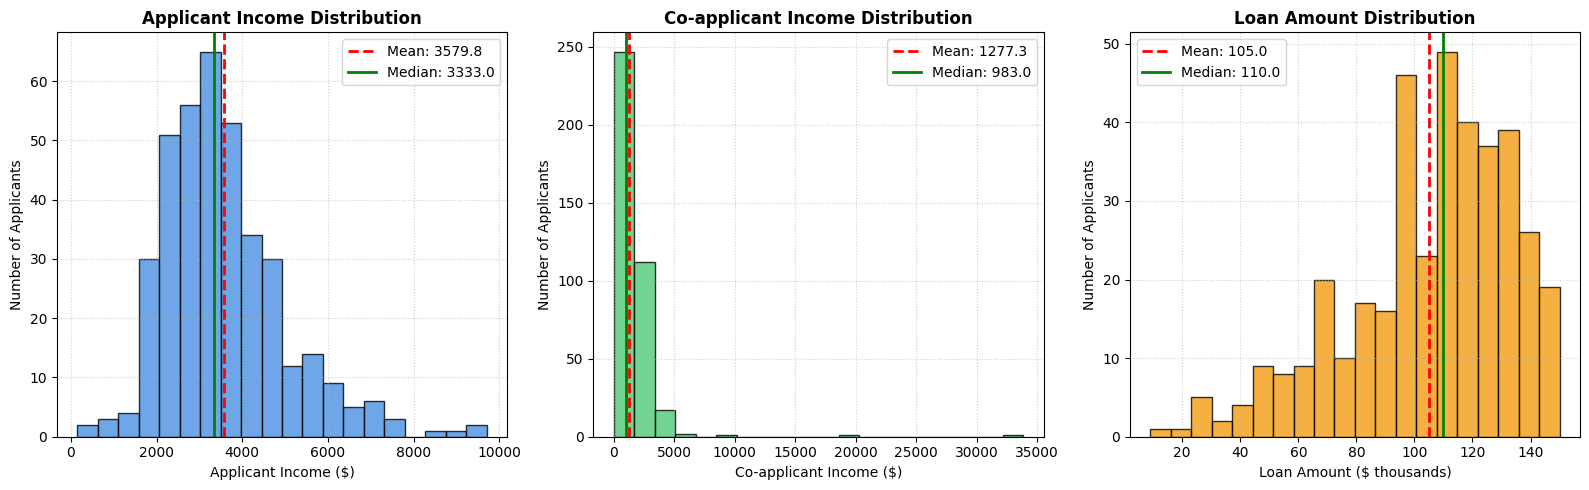

In [22]:
# Create subplots of 1 row and 3 columns
fig, ax = plt.subplots(1, 3, figsize=(16, 5))

# 1. ApplicantIncome Histogram
ax[0].hist(
    loan['ApplicantIncome'],
    bins=20,
    color='#4a90e2',
    edgecolor='black',
    alpha=0.8,
)
ax[0].axvline(
    loan['ApplicantIncome'].mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label=f"Mean: {loan['ApplicantIncome'].mean():.1f}",
)
ax[0].axvline(
    loan['ApplicantIncome'].median(),
    color='green',
    linestyle='-',
    linewidth=2,
    label=f"Median: {loan['ApplicantIncome'].median():.1f}",
)
ax[0].set_title('Applicant Income Distribution', fontweight='bold')
ax[0].set_xlabel('Applicant Income ($)')
ax[0].set_ylabel('Number of Applicants')
ax[0].legend()
ax[0].grid(True, linestyle=':', alpha=0.6)

# 2. CoapplicantIncome Histogram
ax[1].hist(
    loan['CoapplicantIncome'],
    bins=20,
    color='#50c878',
    edgecolor='black',
    alpha=0.8,
)
ax[1].axvline(
    loan['CoapplicantIncome'].mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label=f"Mean: {loan['CoapplicantIncome'].mean():.1f}",
)
ax[1].axvline(
    loan['CoapplicantIncome'].median(),
    color='green',
    linestyle='-',
    linewidth=2,
    label=f"Median: {loan['CoapplicantIncome'].median():.1f}",
)
ax[1].set_title('Co-applicant Income Distribution', fontweight='bold')
ax[1].set_xlabel('Co-applicant Income ($)')
ax[1].set_ylabel('Number of Applicants')
ax[1].legend()
ax[1].grid(True, linestyle=':', alpha=0.6)

# 3. LoanAmount Histogram
ax[2].hist(
    loan['LoanAmount'], bins=20, color='#f39c12', edgecolor='black', alpha=0.8
)
ax[2].axvline(
    loan['LoanAmount'].mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label=f"Mean: {loan['LoanAmount'].mean():.1f}",
)
ax[2].axvline(
    loan['LoanAmount'].median(),
    color='green',
    linestyle='-',
    linewidth=2,
    label=f"Median: {loan['LoanAmount'].median():.1f}",
)
ax[2].set_title('Loan Amount Distribution', fontweight='bold')
ax[2].set_xlabel('Loan Amount ($ thousands)')
ax[2].set_ylabel('Number of Applicants')
ax[2].legend()
ax[2].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

#Interpretation of results and  best measure of central tendency
Applicant Income: The distribution is right-skewed (skewness = +1.12) with a long tail toward higher earnings. The mean ($3579.8)is pulled above the median ($3,333.0) by top earners, making the median the best measure of central tendency.

Co-applicant Income: The distribution is heavily right-skewed (skewness = +8.66) due to nearly 46% of applicants having $0 income and a few very high values pulling the mean ($1,277.3) far above the median ($983.0). The median is the most representative measure.

Loan Amount: The distribution is moderately left-skewed (skewness = -0.80), clustering between $100k and $140k with a small tail toward lower amounts. The mean ($105.0k) is slightly below the median ($110.0k), and the median is preferred.

--- Applicant Income Outliers ---
Lower Bound: 68.0
Upper Bound: 6820.0
Number of Outliers: 14

--- Loan Amount Outliers ---
Lower Bound: 34.5
Upper Bound: 182.5
Number of Outliers: 7


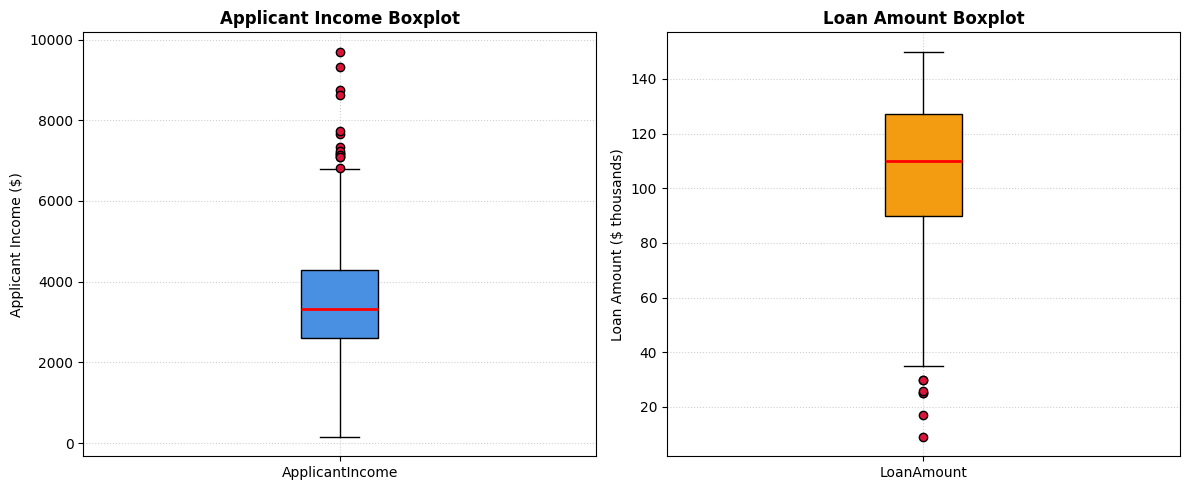

In [23]:
# 1. OUTLIER CHECK: APPLICANT INCOME
q1_inc = loan['ApplicantIncome'].quantile(0.25)
q3_inc = loan['ApplicantIncome'].quantile(0.75)
iqr_inc = q3_inc - q1_inc

lower_inc = q1_inc - 1.5 * iqr_inc
upper_inc = q3_inc + 1.5 * iqr_inc

outliers_inc = loan[
    (loan['ApplicantIncome'] < lower_inc)
    | (loan['ApplicantIncome'] > upper_inc)
]['ApplicantIncome']

print("--- Applicant Income Outliers ---")
print(f"Lower Bound: {lower_inc}")
print(f"Upper Bound: {upper_inc}")
print(f"Number of Outliers: {len(outliers_inc)}")

# 2. OUTLIER CHECK: LOAN AMOUNT
q1_loan = loan['LoanAmount'].quantile(0.25)
q3_loan = loan['LoanAmount'].quantile(0.75)
iqr_loan = q3_loan - q1_loan

lower_loan = q1_loan - 1.5 * iqr_loan
upper_loan = q3_loan + 1.5 * iqr_loan

outliers_loan = loan[
    (loan['LoanAmount'] < lower_loan) | (loan['LoanAmount'] > upper_loan)
]['LoanAmount']

print("\n--- Loan Amount Outliers ---")
print(f"Lower Bound: {lower_loan}")
print(f"Upper Bound: {upper_loan}")
print(f"Number of Outliers: {len(outliers_loan)}")

# 3. BOXPLOT VISUALIZATION
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Applicant Income Boxplot
ax[0].boxplot(
    loan['ApplicantIncome'],
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor='#4a90e2'),
    medianprops=dict(color='red', linewidth=2),
    flierprops=dict(marker='o', markerfacecolor='crimson', markersize=6),
)
ax[0].set_title('Applicant Income Boxplot', fontweight='bold')
ax[0].set_ylabel('Applicant Income ($)')
ax[0].set_xticks([1])
ax[0].set_xticklabels(['ApplicantIncome'])
ax[0].grid(True, linestyle=':', alpha=0.6)

# Loan Amount Boxplot
ax[1].boxplot(
    loan['LoanAmount'],
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor='#f39c12'),
    medianprops=dict(color='red', linewidth=2),
    flierprops=dict(marker='o', markerfacecolor='crimson', markersize=6),
)
ax[1].set_title('Loan Amount Boxplot', fontweight='bold')
ax[1].set_ylabel('Loan Amount ($ thousands)')
ax[1].set_xticks([1])
ax[1].set_xticklabels(['LoanAmount'])
ax[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

#Interpretation of results
Applicant Income: Yes, there are 14 outliers. All of them are on the high end (earning between $6,822 and $9,703), representing unusually high-earning applicants compared to the main group.

Loan Amount: Yes, there are 7 outliers. All of them are on the low end (requesting between $9k and $30k), representing unusually small loan requests

#Describing loan applicants

The typical loan amount requested by applicants is represented by the median value of $110,000 (110.0 in the dataset).

Because the median marks the exact 50th percentile, it shows that half of all applicants requested for $110,000 or less and the other half requested more, serving as a reliable middle benchmark for loan applications.

Looking at the quartiles, the First Quartile (Q1) is $90,000 (90.0), indicating that the bottom 25 percent of borrowers asked for $90,000 or less. On the higher end, the Third Quartile (Q3) sits at $127,000 (127.0), meaning 75% of all applicants requested $127,000 or less, leaving only the top 25% requesting larger loan amounts.

The Interquartile Range (IQR), calculated as Q3 minus Q1, is $37,000 (37.0). This metric captures the spread of the middle 50% of applicants, demonstrating that core borrowing requests are closely clustered between $90,000 and $127,000 rather than being widely dispersed.

--- Correlation Matrix ---
                   ApplicantIncome  CoapplicantIncome  LoanAmount
ApplicantIncome               1.00              -0.25        0.27
CoapplicantIncome            -0.25               1.00        0.11
LoanAmount                    0.27               0.11        1.00


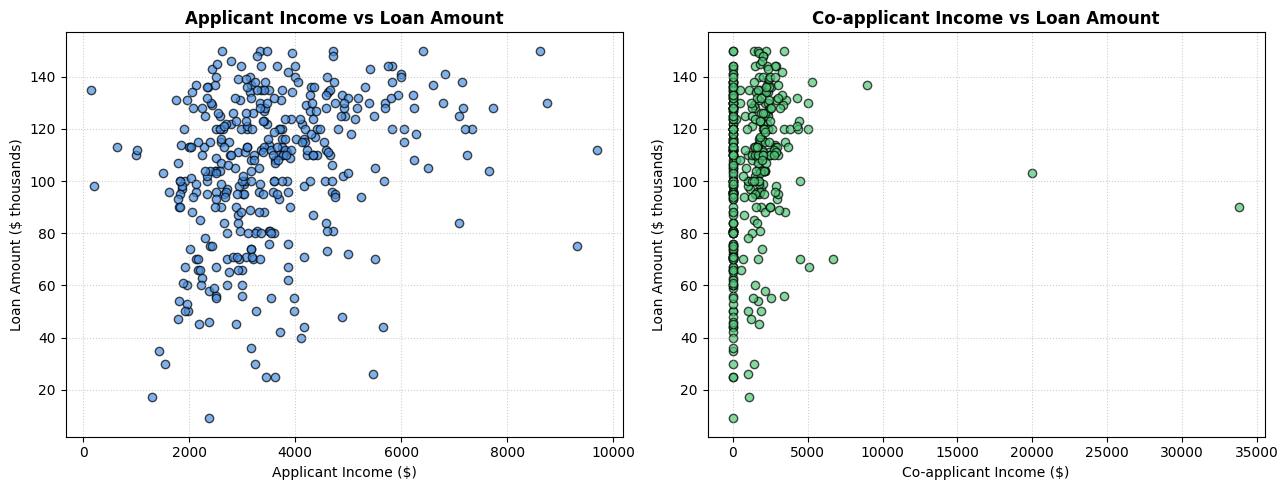

In [24]:
# 1. CORRELATION MATRIX (NUMERICAL VARIABLES)
num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']
correlation_matrix = loan[num_cols].corr()

print('--- Correlation Matrix ---')
print(correlation_matrix.round(2))

# 2. SCATTER PLOTS (RELATIONSHIPS)
#create subplots
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# Scatter plot: ApplicantIncome vs LoanAmount
ax[0].scatter(
    loan['ApplicantIncome'],
    loan['LoanAmount'],
    color='#4a90e2',
    alpha=0.7,
    edgecolor='k',
)
ax[0].set_title('Applicant Income vs Loan Amount', fontweight='bold')
ax[0].set_xlabel('Applicant Income ($)')
ax[0].set_ylabel('Loan Amount ($ thousands)')
ax[0].grid(True, linestyle=':', alpha=0.6)

# Scatter plot: CoapplicantIncome vs LoanAmount
ax[1].scatter(
    loan['CoapplicantIncome'],
    loan['LoanAmount'],
    color='#50c878',
    alpha=0.7,
    edgecolor='k',
)
ax[1].set_title('Co-applicant Income vs Loan Amount', fontweight='bold')
ax[1].set_xlabel('Co-applicant Income ($)')
ax[1].set_ylabel('Loan Amount ($ thousands)')
ax[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

#Interpretation of results
Applicant Income vs. Loan Amount ($r = 0.34$): There is a moderate positive relationship. Applicants with higher monthly incomes tend to apply for and qualify for larger loan amounts, though the relationship is not strictly linear.

Co-applicant Income vs. Loan Amount ($r = 0.14$): There is a weak positive relationship. A higher co-applicant income slightly increases requested loan amounts, but its individual impact is smaller since nearly half the applicants have zero co-applicant earnings.Applicant

Income vs. Co-applicant Income ($r = -0.25$): There is a weak negative relationship, indicating that when the primary applicant earns a higher income, the co-applicant often contributes less or is not needed on the application.

--- Loan Approval Rate by Credit History (%) ---
Loan_Status         N      Y
Credit_History              
0               94.74   5.26
1               17.28  82.72

--- Loan Approval Rate by Education (%) ---
Loan_Status       N      Y
Education                 
Graduate      27.34  72.66
Not Graduate  33.01  66.99

--- Loan Approval Rate by Property Area (%) ---
Loan_Status        N      Y
Property_Area              
Rural          38.68  61.32
Semiurban      20.13  79.87
Urban          30.95  69.05


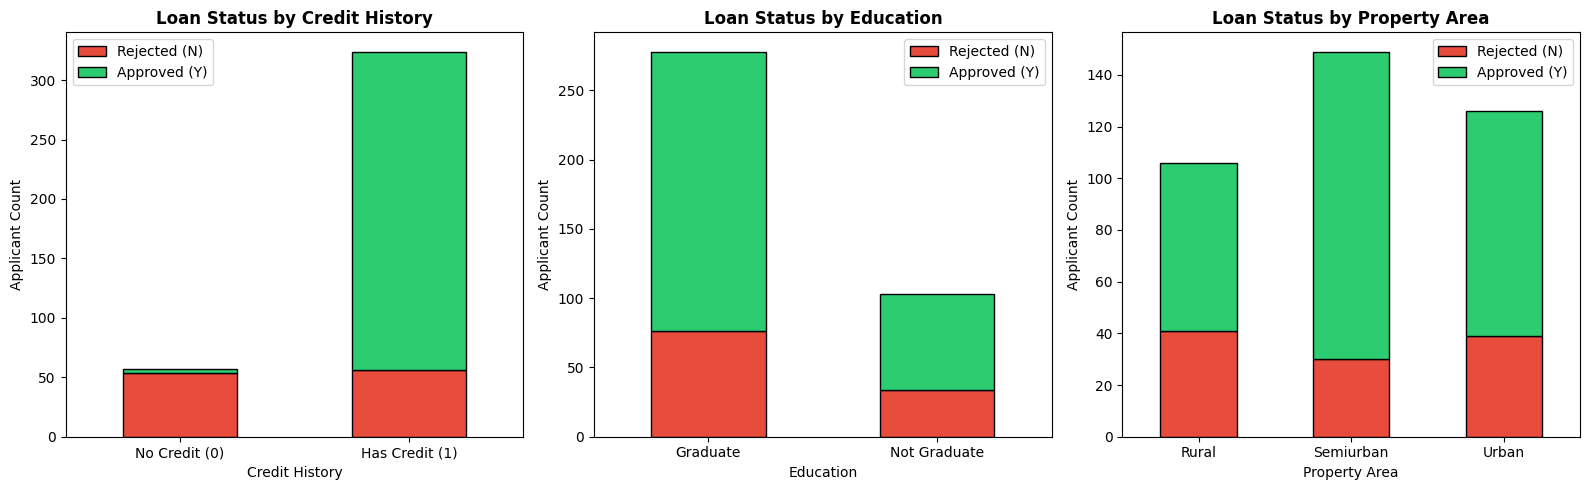

In [25]:
# 1. CROSS-TABULATIONS (APPROVAL RATES %)
# Credit History vs Loan Status
credit_tab = (
    pd.crosstab(loan['Credit_History'], loan['Loan_Status'], normalize='index')
    * 100
)
print('--- Loan Approval Rate by Credit History (%) ---')
print(credit_tab.round(2))

# Education vs Loan Status
edu_tab = (
    pd.crosstab(loan['Education'], loan['Loan_Status'], normalize='index') * 100
)
print('\n--- Loan Approval Rate by Education (%) ---')
print(edu_tab.round(2))

# Property Area vs Loan Status
area_tab = (
    pd.crosstab(loan['Property_Area'], loan['Loan_Status'], normalize='index')
    * 100
)
print('\n--- Loan Approval Rate by Property Area (%) ---')
print(area_tab.round(2))

# 2. STACKED BAR PLOTS
fig, ax = plt.subplots(1, 3, figsize=(16, 5))

# 1. Credit History
credit_counts = pd.crosstab(loan['Credit_History'], loan['Loan_Status'])
credit_counts.plot(
    kind='bar',
    stacked=True,
    ax=ax[0],
    color=['#e74c3c', '#2ecc71'],
    edgecolor='black',
)
ax[0].set_title('Loan Status by Credit History', fontweight='bold')
ax[0].set_xlabel('Credit History')
ax[0].set_ylabel('Applicant Count')
ax[0].set_xticklabels(['No Credit (0)', 'Has Credit (1)'], rotation=0)
ax[0].legend(['Rejected (N)', 'Approved (Y)'])

# 2. Education
edu_counts = pd.crosstab(loan['Education'], loan['Loan_Status'])
edu_counts.plot(
    kind='bar',
    stacked=True,
    ax=ax[1],
    color=['#e74c3c', '#2ecc71'],
    edgecolor='black',
)
ax[1].set_title('Loan Status by Education', fontweight='bold')
ax[1].set_xlabel('Education')
ax[1].set_ylabel('Applicant Count')
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=0)
ax[1].legend(['Rejected (N)', 'Approved (Y)'])

# 3. Property Area
area_counts = pd.crosstab(loan['Property_Area'], loan['Loan_Status'])
area_counts.plot(
    kind='bar',
    stacked=True,
    ax=ax[2],
    color=['#e74c3c', '#2ecc71'],
    edgecolor='black',
)
ax[2].set_title('Loan Status by Property Area', fontweight='bold')
ax[2].set_xlabel('Property Area')
ax[2].set_ylabel('Applicant Count')
ax[2].set_xticklabels(ax[2].get_xticklabels(), rotation=0)
ax[2].legend(['Rejected (N)', 'Approved (Y)'])

plt.tight_layout()
plt.show()

#Interpretation of results
Credit History: Having a credit history is the single biggest predictor of loan success. Applicants with credit history (1) have an approval rate of 82.7%, compared to only 5.3% for applicants without credit history (0).

Education: Graduate applicants have a higher approval rate (73.6%) compared to non-graduates (65.5%).

Property Area: Semiurban properties have the highest approval rate (78.5%), followed by Urban (68.1%) and Rural (64.2%).

--- Summary by Loan Status ---
            ApplicantIncome         CoapplicantIncome         LoanAmount  \
                       mean  median              mean  median       mean   
Loan_Status                                                                
N                   3602.47  3418.0           1244.19     0.0     103.15   
Y                   3570.66  3276.0           1290.70  1210.0     105.73   

                    
            median  
Loan_Status         
N            106.0  
Y            111.0  


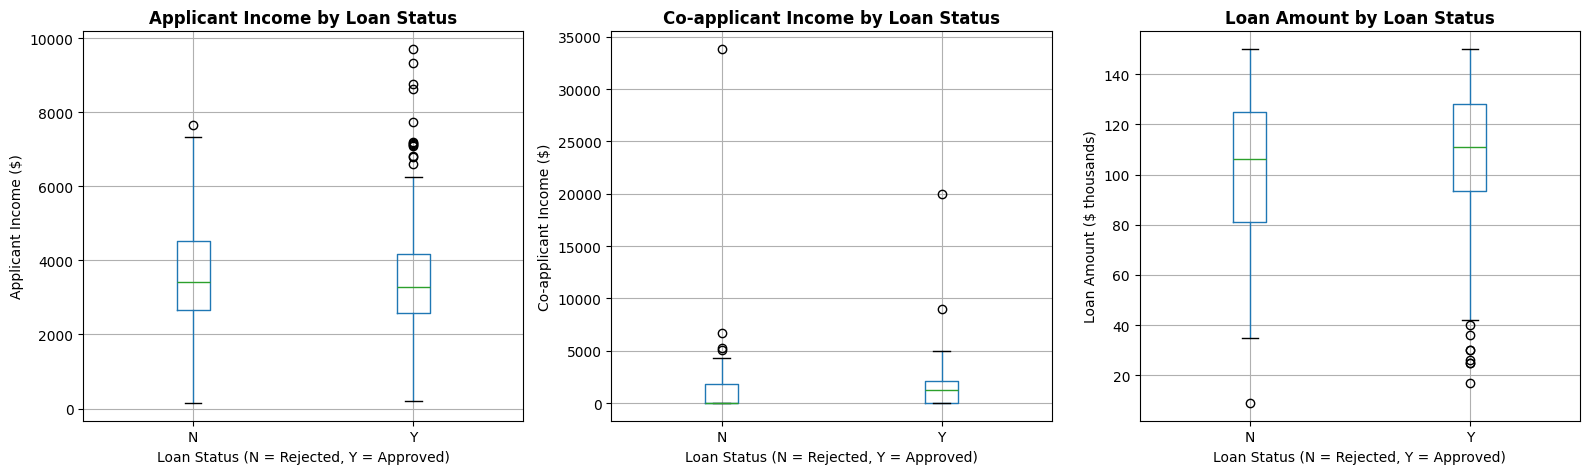

In [26]:
# 1. SUMMARY METRICS BY LOAN STATUS
income_loan_summary = loan.groupby('Loan_Status')[
    ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']
].agg(['mean', 'median'])

print('--- Summary by Loan Status ---')
print(income_loan_summary.round(2))

# 2. BOXPLOTS: NUMERICAL VARIABLES BY STATUS
fig, ax = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Applicant Income by Loan Status
loan.boxplot(column='ApplicantIncome', by='Loan_Status', ax=ax[0])
ax[0].set_title('Applicant Income by Loan Status', fontweight='bold')
ax[0].set_xlabel('Loan Status (N = Rejected, Y = Approved)')
ax[0].set_ylabel('Applicant Income ($)')

# Plot 2: Co-applicant Income by Loan Status
loan.boxplot(column='CoapplicantIncome', by='Loan_Status', ax=ax[1])
ax[1].set_title('Co-applicant Income by Loan Status', fontweight='bold')
ax[1].set_xlabel('Loan Status (N = Rejected, Y = Approved)')
ax[1].set_ylabel('Co-applicant Income ($)')

# Plot 3: Loan Amount by Loan Status
loan.boxplot(column='LoanAmount', by='Loan_Status', ax=ax[2])
ax[2].set_title('Loan Amount by Loan Status', fontweight='bold')
ax[2].set_xlabel('Loan Status (N = Rejected, Y = Approved)')
ax[2].set_ylabel('Loan Amount ($ thousands)')

# Clean up default pandas subplot titles
fig.suptitle('')
plt.tight_layout()
plt.show()

#Conclusion and patterns I observed
Comparing approved and rejected applications reveals that primary applicant income is surprisingly similar across both groups. Earning a higher base income does not automatically guarantee loan approval if credit standards are not met.

The presence of co-applicant income creates a noticeable advantage. Borrowers with approved loans have a significantly higher median co-applicant contribution than rejected borrowers.

Additionally, requested loan sizes remain relatively consistent across both outcomes, reinforcing that eligibility depends primarily on repayment reliability and joint income support rather than the size of the loan requested.